<a href="https://colab.research.google.com/github/urashlei/mliot-pyml-2026-hw/blob/main/week04/Homework_b7/nguyenbaotien_hw07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# **Bài 1: Titanic Dataset**

In [56]:
# tải dữ liệu
titanic = sns.load_dataset('titanic')

**pre processing**

In [57]:
# chọn các cột đặc trưng
features=['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X=titanic[features].copy()
y=titanic['survived']

# xử lý missing values
X['age'] = X['age'].fillna(X['age'].median())
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])
X['fare'] = X['fare'].fillna(X['fare'].median())

# chuyển thành số nhị phân
X=pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=True)

print('Số đặc trưng sau mã hóa:', X.shape[1])

Số đặc trưng sau mã hóa: 8


**chia dữ liệu train/test**

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Kích thước train: {X_train.shape}, test: {X_test.shape}')

Kích thước train: (712, 8), test: (179, 8)


**chuẩn hóa data**

In [59]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print('Đã chuẩn hóa data')

Đã chuẩn hóa data


**huấn luyện và đánh giá logistic regression**

In [60]:
logreg=LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# dự đoán trên test
y_pred_log=logreg.predict(X_test_scaled)

# chỉ số
acc=accuracy_score(y_test, y_pred_log)
pre=precision_score(y_test, y_pred_log)
rec=recall_score(y_test, y_pred_log)
f1=f1_score(y_test, y_pred_log)
cm=confusion_matrix(y_test, y_pred_log)

print('Logistic Regression:')
print(f'Accuracy: {acc:.4f}')
print(f'Precision: {pre:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1-score: {f1:.4f}')
print('Confusion Matrix:')
print(cm)

Logistic Regression:
Accuracy: 0.8101
Precision: 0.7857
Recall: 0.7432
F1-score: 0.7639
Confusion Matrix:
[[90 15]
 [19 55]]


**so sánh**

In [61]:
#linear Regression
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred_lin=linreg.predict(X_test_scaled)
y_pred_lin_bin=(y_pred_lin >= 0.5).astype(int)

# chỉ số
acc_lin=accuracy_score(y_test, y_pred_lin_bin)
pre_lin=precision_score(y_test, y_pred_lin_bin)
rec_lin=recall_score(y_test, y_pred_lin_bin)
f1_lin=f1_score(y_test, y_pred_lin_bin)
cm_lin=confusion_matrix(y_test, y_pred_lin_bin)

print('Linear Regression:')
print(f'Accuracy: {acc_lin:.4f}')
print(f'Precision: {pre_lin:.4f}')
print(f'Recall: {rec_lin:.4f}')
print(f'F1-score: {f1_lin:.4f}')
print('Confusion Matrix:')
print(cm_lin)

Linear Regression:
Accuracy: 0.7933
Precision: 0.7681
Recall: 0.7162
F1-score: 0.7413
Confusion Matrix:
[[89 16]
 [21 53]]


**Nhận xét**
- Accuracy: Logistic Regression thường cho độ chính xác cao hơn Linear Regression vì Logistic Regression dc thiết kế cho bài toán phân loại nhị phân với hàm sigmoid ánh xạ đầu ra vào khoảng (0,1) phù hợp để biểu diễn xác suất. Trong khi đó, Linear Regression dự đoán giá trị liên tục có thể vượt ngoài khoảng [0,1], dẫn đến việc phân loại sai khi áp dụng ngưỡng 0.5

- Precision: Precision cho biết trong số các hành khách được dự đoán là sống sót, có bao nhiêu người thực sự sống sót. Logistic Regression có Precision tốt hơn vì nó tối ưu xác suất dự đoán, giúp giảm số lượng dự đoán dương tính giả. Linear Regression có thể bị ảnh hưởng bởi outliers làm sai lệch đường hồi quy và dẫn đến Precision thấp hơn

- Recall: Recall đo lường khả năng mô hình phát hiện đúng những hành khách thực sự sống sót. Logistic Regression thường có Recall cân bằng hơn vì nó học trực tiếp từ xác suất có điều kiện P(y=1|x). Linear Regression có thể cho Recall không ổn định do không tối ưu trực tiếp cho bài toán phân loại.

- F1-score: F1-score thể hiện sự cân bằng giữa hai chỉ số Precision và Recall. Logistic Regression có F1-score cao hơn cho thấy nó đạt được sự cân bằng tốt hơn giữa việc phát hiện đúng các trường hợp sống sót và tránh dự đoán sai.

- Confusion Matrix: Logistic Regression thường có số dự đoán đúng (TP và TN) cao hơn, ít sai sót hơn. Linear Regression thường có nhiều sai sót hơn, đặc biệt là dự đoán sai đối với các trường hợp sống sót (FN) hoặc dự đoán sống sót sai (FP) do mô hình không phù hợp với bản chất rời rạc của nhãn.

==> Logistic Regression là mô hình phù hợp hơn cho bài toán dự đoán khả năng sống sót của hành khách Titanic vì:
+ Đây là bài toán phân loại nhị phân, yêu cầu dự đoán xác suất thuộc một trong hai lớp. Logistic Regression được thiết kế riêng cho mục đích này, với đầu ra là xác suất trong khoảng (0,1), có thể giải thích một cách tự nhiên.
+ Logistic Regression sử dụng hàm sigmoid để tạo ra quyết định phân loại giúp mô hình học được các mối quan hệ phi tuyến giữa đặc trưng và nhãn một cách hiệu quả.
+ Xác suất đầu ra từ Logistic Regression có ý nghĩa thực tế rõ ràng (vd một hành khách có 85% khả năng sống sót), giúp đưa ra quyết định có căn cứ hơn.
+ Logistic Regression ít bị ảnh hưởng bởi các outliers và cho kết quả ổn định hơn so với Linear Regression khi áp dụng cho bài toán phân loại.



# **Bài 2: Dry Bean Dataset**

In [62]:
train_df = pd.read_csv('/content/dry_bean_train.csv')
test_df = pd.read_csv('/content/dry_bean_test.csv')

print("Kích thước train:", train_df.shape)
print("Kích thước test:", test_df.shape)
print("Các lớp trong train:", train_df['class'].unique())

Kích thước train: (10834, 17)
Kích thước test: (2709, 17)
Các lớp trong train: ['CALI' 'BARBUNYA' 'HOROZ' 'SIRA' 'DERMASON' 'SEKER' 'BOMBAY']


In [63]:
X_train = train_df.drop('class', axis=1)
y_train = train_df['class']
X_test = test_df.drop('class', axis=1)
y_test = test_df['class']

# mã hóa nhãn thành số
le=LabelEncoder()
y_train_enc=le.fit_transform(y_train)
y_test_enc=le.transform(y_test)

class_names=le.classes_
print('Các lớp:', dict(zip(class_names, range(len(class_names)))))

Các lớp: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


**chuẩn hóa dữ liệu**

In [64]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print('đã chuẩn hóa dữ liệu')

đã chuẩn hóa dữ liệu


**logistic regression**

In [65]:
logreg=LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train_enc)
y_pred_lr=logreg.predict(X_test_scaled)

# các chỉ số
acc_lr=accuracy_score(y_test_enc, y_pred_lr)
pre_lr=precision_score(y_test_enc, y_pred_lr, average='macro')
rec_lr=recall_score(y_test_enc, y_pred_lr, average='macro')
f1_lr=f1_score(y_test_enc, y_pred_lr, average='macro')

print('Logistic Regression:')
print(f'Accuracy: {acc_lr:.4f}')
print(f'Precision(macro): {pre_lr:.4f}')
print(f'Recall(macro): {rec_lr:.4f}')
print(f'F1-score(macro): {f1_lr:.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test_enc, y_pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression:
Accuracy: 0.9192
Precision(macro): 0.9307
Recall(macro): 0.9300
F1-score(macro): 0.9302
Confusion Matrix:
[[236   0  18   0   0   4   7]
 [  0 104   0   0   0   0   0]
 [  8   0 307   0   5   2   4]
 [  0   0   0 643   0  13  53]
 [  1   0  11   5 351   0   4]
 [  9   0   0   5   0 383   9]
 [  1   0   1  41   8  10 466]]


**tìm K tối ưu**

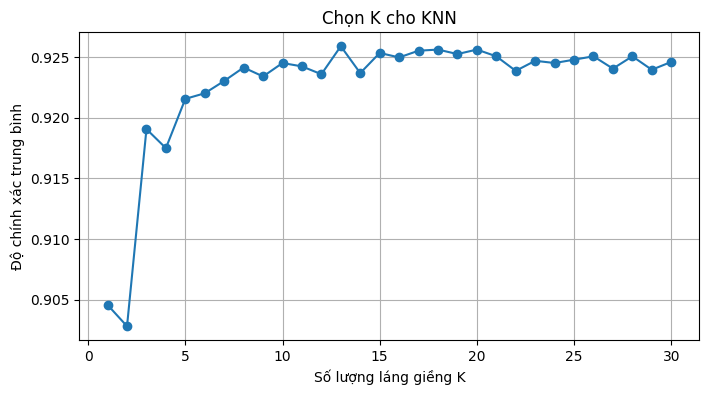

K tối ưu: 13 với độ chính xác CV: 0.9259


In [66]:
k_range=range(1, 31)
cv_scores=[]
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_enc, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(8,4))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('Số lượng láng giềng K')
plt.ylabel('Độ chính xác trung bình')
plt.title('Chọn K cho KNN')
plt.grid(True)
plt.show()

best_k=k_range[np.argmax(cv_scores)]
print(f'K tối ưu: {best_k} với độ chính xác CV: {max(cv_scores):.4f}')

**huấn luyện knn**

In [67]:
knn_best=KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train_enc)
y_pred_knn = knn_best.predict(X_test_scaled)

acc_knn=accuracy_score(y_test_enc, y_pred_knn)
pre_knn=precision_score(y_test_enc, y_pred_knn, average='macro')
rec_knn=recall_score(y_test_enc, y_pred_knn, average='macro')
f1_knn=f1_score(y_test_enc, y_pred_knn, average='macro')

print('KNN:')
print(f'K = {best_k}')
print(f'Accuracy: {acc_knn:.4f}')
print(f'Precision(macro): {pre_knn:.4f}')
print(f'Recall(macro): {rec_knn:.4f}')
print(f'F1-score(macro): {f1_knn:.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test_enc, y_pred_knn))

KNN:
K = 13
Accuracy: 0.9162
Precision(macro): 0.9311
Recall(macro): 0.9272
F1-score(macro): 0.9287
Confusion Matrix:
[[233   0  20   0   1   4   7]
 [  0 104   0   0   0   0   0]
 [  3   0 312   0   6   2   3]
 [  0   0   0 644   0  13  52]
 [  0   0  14   5 345   0   8]
 [  5   0   0   7   0 383  11]
 [  4   0   1  50   6   5 461]]


**so sánh**

In [68]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', f'KNN (K={best_k})'],
    'Accuracy': [acc_lr, acc_knn],
    'Precision (macro)': [pre_lr, pre_knn],
    'Recall (macro)': [rec_lr, rec_knn],
    'F1-score (macro)': [f1_lr, f1_knn]
})

print(comparison.to_string(index=False))

              Model  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
Logistic Regression  0.919158           0.930725        0.930049          0.930237
         KNN (K=13)  0.916205           0.931087        0.927165          0.928721


# **So sánh Logistic Regression và KNN:**
- Accuracy: Logistic Regression có Accuracy cao hơn (91.92% so với 91.62%). Sự chênh lệch không lớn cho lắm cho thấy cả hai mô hình đều hoạt động tốt.

- Precision (macro): KNN có Precision cao hơn một chút (93.11% so với 93.07%). Sự khác biệt rất nhỏ, cả hai đều có tỉ lệ dự đoán đúng trong số các mẫu được gán vào một lớp là rất cao. KNN nhỉnh hơn trong việc tránh dự đoán sai (dương tính giả) cho từng lớp.
- Recall (macro): Logistic Regression có Recall cao hơn (93.00% so với 92.72%). Logistic Regression phát hiện được nhiều mẫu đúng của từng lớp hơn, nghĩa là ít bỏ sót các mẫu thuộc một lớp hơn.

- F1-score (macro): Logistic Regression có F1-score cao hơn (93.02% so với 92.87%), cho thấy Logistic Regression có sự cân bằng tổng thể tốt hơn một chút.

==> Sự khác biệt giữa hai mô hình là rất nhỏ, không có mô hình nào vượt trội hoàn toàn.

==> Với bài toán phân loại các loại hạt đậu (Dry Bean Dataset):

+ Logistic Regression là mô hình phù hợp hơn một chút, với Accuracy và F1-score cao hơn và sự cân bằng tốt hơn giữa Precision và Recall.
+ Thời gian huấn luyện và dự đoán nhanh hơn.
+ Dễ giải thích hơn (có thể hiểu trọng số của từng đặc trưng).